# NGHIÊN CỨU DỰ BÁO XÁC SUẤT VỠ NỢ THẺ TÍN DỤNG QUA MÔ HÌNH HỒI QUY LOGISTIC THUẦN TÚY
## (Credit Card Default Prediction — Pure NumPy Logistic Regression)

**Tập dữ liệu:** Default of Credit Card Clients — Yeh & Lien (2009), UCI ML Repository
**Không gian mẫu:** 30,000 hồ sơ khách hàng × 23 biến gốc → mở rộng 27 biến qua Feature Engineering
**Thuật toán:** Hồi quy Logistic với Gradient Descent, điều chuẩn L1/L2 — triển khai thuần NumPy


In [1]:
# ====================================================================
# KHỞI TẠO MÔI TRƯỜNG — Import toàn bộ thư viện và module tự xây dựng
# ====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, json, warnings
warnings.filterwarnings('ignore')

from model import (
    LogisticRegression, StandardScaler, train_test_split,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, average_precision_score,
    StratifiedKFold, GridSearchCV, CreditDefaultInferencePipeline
)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
print("Môi trường khởi tạo thành công.")
print("Toàn bộ thuật toán vận hành trên nền tảng NumPy thuần túy.")


Môi trường khởi tạo thành công.
Toàn bộ thuật toán vận hành trên nền tảng NumPy thuần túy.


## Bước 1: Xác định bài toán (Problem Definition)

Dự báo nguy cơ khách hàng vỡ nợ thẻ tín dụng ($y = 1$) vào tháng tiếp theo dựa trên 23 đặc trưng lịch sử tài chính, nhân khẩu học và hành vi thanh toán.

Đặc tính bài toán: **Tổn thất phi đối xứng (Asymmetric Risk)** — Chi phí bỏ sót một khách hàng nợ xấu (False Negative) gây thiệt hại tín dụng trực tiếp lớn hơn nhiều so với chi phí từ chối nhầm một khách hàng tốt (False Positive).

Do dữ liệu mất cân bằng và chi phí bỏ sót khách hàng có nguy cơ vỡ nợ cao, mô hình ưu tiên Recall và F1-score thay vì chỉ tối ưu Accuracy. `class_weight='balanced'` được sử dụng để điều chỉnh trọng số giữa các lớp khi tối ưu hàm mất mát.


In [2]:
# Định hướng mục tiêu bài toán và xử lý tổn thất bất đối xứng
# Do dữ liệu mất cân bằng và chi phí bỏ sót khách hàng có nguy cơ vỡ nợ cao (False Negative),
# mô hình ưu tiên Recall và F1-score thay vì chỉ tối ưu Accuracy.
# class_weight='balanced' sẽ được sử dụng trong hàm mất mát để điều chỉnh trọng số giữa các lớp.

print("=" * 70)
print("ĐỊNH HƯỚNG BÀI TOÁN DỰ BÁO VỠ NỢ THẺ TÍN DỤNG")
print("=" * 70)
print("  - Bản chất: Phân loại nhị phân trên dữ liệu mất cân bằng (Imbalanced Data)")
print("  - Rủi ro phi đối xứng: False Negative (bỏ sót nợ xấu) >> False Positive (cảnh báo nhầm)")
print("  - Chiến lược tối ưu: Ưu tiên Recall và F1-Score qua class_weight='balanced' và tinh chỉnh ngưỡng quyết định")
print("=" * 70)


ĐỊNH HƯỚNG BÀI TOÁN DỰ BÁO VỠ NỢ THẺ TÍN DỤNG
  - Bản chất: Phân loại nhị phân trên dữ liệu mất cân bằng (Imbalanced Data)
  - Rủi ro phi đối xứng: False Negative (bỏ sót nợ xấu) >> False Positive (cảnh báo nhầm)
  - Chiến lược tối ưu: Ưu tiên Recall và F1-Score qua class_weight='balanced' và tinh chỉnh ngưỡng quyết định


## Bước 2: Xác định bản chất của bài toán Machine Learning

Phân loại nhị phân có giám sát — nhãn mục tiêu là `default payment next month` nhận giá trị 0 (đúng hạn) hoặc 1 (nợ xấu). Đầu ra mong muốn là xác suất liên tục $\hat{p} \in [0, 1]$ chứ không chỉ nhãn cứng.


In [3]:
# Thiết lập các thông số nền tảng
ml_paradigm = {
    'Learning Type': 'Supervised Learning (Học có giám sát)',
    'Task Type': 'Binary Classification (Phân loại nhị phân)',
    'Algorithm': 'Logistic Regression (Gradient Descent, NumPy thuần túy)',
    'Output': 'Xác suất liên tục p(y=1|x) qua hàm Sigmoid',
    'Input Dimension': 23,
    'Target Space': '{0: Đúng hạn, 1: Nợ xấu}',
    'Random State': 42
}

for k, v in ml_paradigm.items():
    print(f"  {k:18s}: {v}")


  Learning Type     : Supervised Learning (Học có giám sát)
  Task Type         : Binary Classification (Phân loại nhị phân)
  Algorithm         : Logistic Regression (Gradient Descent, NumPy thuần túy)
  Output            : Xác suất liên tục p(y=1|x) qua hàm Sigmoid
  Input Dimension   : 23
  Target Space      : {0: Đúng hạn, 1: Nợ xấu}
  Random State      : 42


## Bước 3: Khảo sát lĩnh vực và không gian dữ liệu (Domain & Data Understanding)

Tập dữ liệu gốc gồm 30,000 hồ sơ khách hàng tại Đài Loan (Yeh & Lien, 2009).
23 biến độc lập chia thành 5 nhóm nghiệp vụ: hạn mức, nhân khẩu học, lịch sử trả nợ, dư nợ sao kê, và số tiền thanh toán thực tế.


In [4]:
# Nạp dữ liệu thô và phân loại 5 nhóm đặc trưng nghiệp vụ
df_raw = pd.read_csv('default_of_credit_card_clients.csv')
feature_groups = {
    'Hạn mức tín dụng': ['LIMIT_BAL'],
    'Nhân khẩu học': ['SEX', 'EDUCATION', 'MARRIAGE', 'AGE'],
    'Lịch sử trả nợ (6 tháng)': ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6'],
    'Dư nợ sao kê (6 tháng)': ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6'],
    'Số tiền thanh toán (6 tháng)': ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
}

print(f"Kích thước tập dữ liệu: {df_raw.shape[0]:,} dòng × {df_raw.shape[1]} cột")
print(f"Giá trị thiếu: {df_raw.isnull().sum().sum()}")
print()
for group_name, cols in feature_groups.items():
    print(f"  {group_name:30s}: {len(cols)} biến ({', '.join(cols[:3])}{'...' if len(cols)>3 else ''})")


Kích thước tập dữ liệu: 30,000 dòng × 25 cột
Giá trị thiếu: 0

  Hạn mức tín dụng              : 1 biến (LIMIT_BAL)
  Nhân khẩu học                 : 4 biến (SEX, EDUCATION, MARRIAGE...)
  Lịch sử trả nợ (6 tháng)      : 6 biến (PAY_0, PAY_2, PAY_3...)
  Dư nợ sao kê (6 tháng)        : 6 biến (BILL_AMT1, BILL_AMT2, BILL_AMT3...)
  Số tiền thanh toán (6 tháng)  : 6 biến (PAY_AMT1, PAY_AMT2, PAY_AMT3...)


## Bước 4: Khám phá và xử lý dữ liệu (Data Exploration & Cleaning)

Khám phá tập trung vào mức độ mất cân bằng nhãn. Với tỷ lệ 3.52 : 1, nghiên cứu không dùng SMOTE mà xử lý bằng cân bằng trọng số lớp và tinh chỉnh ngưỡng ở phần sau.


Tổng số quan sát: 30,000
Nhóm 0 (Đúng hạn) : 23,364 (77.88%)
Nhóm 1 (Nợ xấu)   : 6,636 (22.12%)
Tỷ lệ mất cân bằng: 3.52 : 1


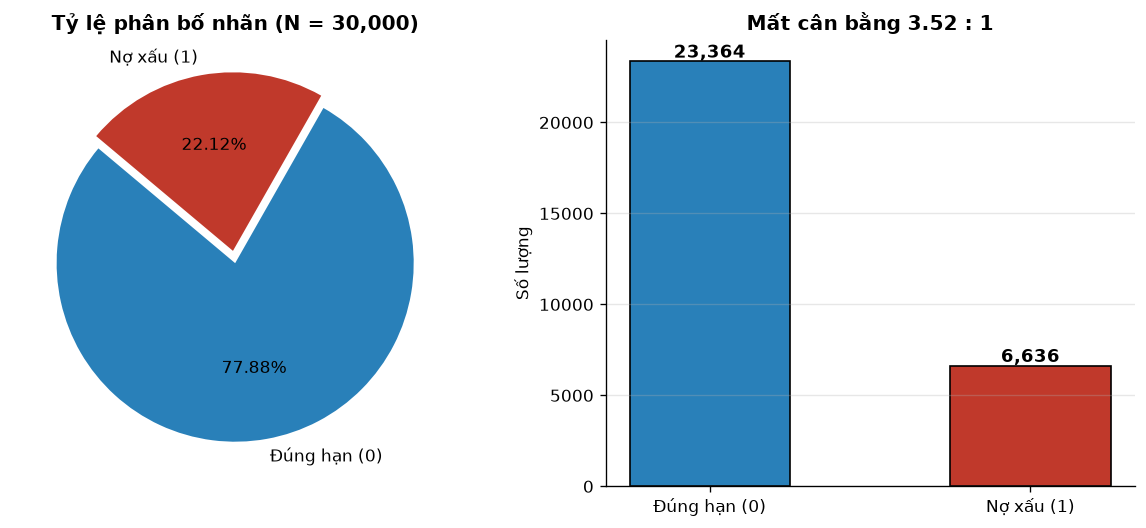

In [5]:
# Trực quan hóa phân bố nhãn
c0_count = int((df_raw['default payment next month'] == 0).sum())
c1_count = int((df_raw['default payment next month'] == 1).sum())
total_samples = len(df_raw)
imbalance_ratio = c0_count / c1_count

print(f"Tổng số quan sát: {total_samples:,}")
print(f"Nhóm 0 (Đúng hạn) : {c0_count:,} ({c0_count/total_samples*100:.2f}%)")
print(f"Nhóm 1 (Nợ xấu)   : {c1_count:,} ({c1_count/total_samples*100:.2f}%)")
print(f"Tỷ lệ mất cân bằng: {imbalance_ratio:.2f} : 1")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))
labels = ['Đúng hạn (0)', 'Nợ xấu (1)']
colors = ['#2980b9', '#c0392b']

ax1.pie([c0_count, c1_count], labels=labels, colors=colors, autopct='%1.2f%%',
        startangle=140, explode=(0, 0.07), textprops={'fontsize': 10})
ax1.set_title(f'Tỷ lệ phân bố nhãn (N = {total_samples:,})', fontweight='bold')

bars = ax2.bar(labels, [c0_count, c1_count], color=colors, edgecolor='black', width=0.5)
for bar, cnt in zip(bars, [c0_count, c1_count]):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
             f'{cnt:,}', ha='center', fontsize=11, fontweight='bold')
ax2.set_ylabel('Số lượng'); ax2.set_title(f'Mất cân bằng {imbalance_ratio:.2f} : 1', fontweight='bold')
ax2.grid(axis='y', alpha=0.3); ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


## Bước 5: Chuẩn hóa đặc trưng (Feature Scaling & Scale Invariance)

`LIMIT_BAL` đạt quy mô $10^6$ trong khi `AGE` chỉ ở mức $10^1$. Sự chênh lệch này kéo giãn mặt cắt hàm mất mát và làm Gradient Descent dao động mạnh.
Chuẩn hóa Z-Score: $z_j = (x_j - \mu_j) / \sigma_j$ — tham số $\mu, \sigma$ chỉ ước lượng trên tập train.


In [6]:
# Khảo sát chênh lệch thang đo
cols_inspect = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1', 'PAY_0']
stats_df = df_raw[cols_inspect].describe().T[['min', 'mean', 'std', 'max']]
print("Thống kê mô tả trước khi chuẩn hóa:")
print(stats_df.to_string())
print()
print(f"Khoảng biến thiên LIMIT_BAL: {df_raw['LIMIT_BAL'].max() - df_raw['LIMIT_BAL'].min():,.0f}")
print(f"Khoảng biến thiên AGE      : {df_raw['AGE'].max() - df_raw['AGE'].min()}")
print("→ Z-Score là điều kiện tiên quyết để Gradient Descent hội tụ ổn định.")


Thống kê mô tả trước khi chuẩn hóa:


                min           mean            std        max
LIMIT_BAL   10000.0  167484.322667  129747.661567  1000000.0
AGE            21.0      35.485500       9.217904       79.0
BILL_AMT1 -165580.0   51223.330900   73635.860576   964511.0
PAY_AMT1        0.0    5663.580500   16563.280354   873552.0
PAY_0          -2.0      -0.016700       1.123802        8.0

Khoảng biến thiên LIMIT_BAL: 990,000
Khoảng biến thiên AGE      : 58
→ Z-Score là điều kiện tiên quyết để Gradient Descent hội tụ ổn định.


## Bước 6: Xử lý biến phân loại (Categorical Data & Encoding)

Cột `EDUCATION` chứa mã ngoài tài liệu (0, 5, 6) — gộp về nhóm 4 ('Khác'). Cột `MARRIAGE` có mã 0 — gộp về nhóm 3.
Các biến thứ bậc `PAY_0..PAY_6` giữ nguyên bản chất số học tự nhiên phản ánh số tháng chậm thanh toán ([-2, 8]).

**Lựa chọn mô hình hóa (Modeling Choice):**
Các biến `EDUCATION` và `MARRIAGE` được duy trì mã hóa số nguyên theo cấu trúc bài toán để giữ không gian đặc trưng compact, tránh phân mảnh bậc tự do và phù hợp với mô hình Hồi quy Logistic chuẩn hóa.


In [7]:
# Xử lý biến phân loại theo chuẩn nghiệp vụ
df = df_raw.copy()
edu_anom = int(((df['EDUCATION'] == 0) | (df['EDUCATION'] == 5) | (df['EDUCATION'] == 6)).sum())
mar_anom = int((df['MARRIAGE'] == 0).sum())

df['EDUCATION'] = df['EDUCATION'].replace([0, 5, 6], 4)
df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3)

print(f"Bản ghi có mã học vấn dị thường (0,5,6) → quy về 4: {edu_anom:,}")
print(f"Bản ghi có mã hôn nhân dị thường (0) → quy về 3    : {mar_anom:,}")
print()
print("Phân bố EDUCATION sau xử lý:")
print(df['EDUCATION'].value_counts().sort_index().to_dict())
print("Phân bố MARRIAGE sau xử lý:")
print(df['MARRIAGE'].value_counts().sort_index().to_dict())


Bản ghi có mã học vấn dị thường (0,5,6) → quy về 4: 345
Bản ghi có mã hôn nhân dị thường (0) → quy về 3    : 54

Phân bố EDUCATION sau xử lý:
{1: 10585, 2: 14030, 3: 4917, 4: 468}
Phân bố MARRIAGE sau xử lý:
{1: 13659, 2: 15964, 3: 377}


## Bước 7: Lựa chọn thuật toán, hàm mục tiêu và hệ số phạt (Algorithm, Objective & Penalty Factor)

Hàm Sigmoid: $\hat{p} = \sigma(z) = \frac{1}{1 + e^{-z}}$, $z = \mathbf{w}^T \mathbf{x} + b$

Hàm mất mát kết hợp điều chuẩn:
$$J = -\frac{1}{N}\sum[y\log(\hat{p}) + (1-y)\log(1-\hat{p})] + \lambda R(\mathbf{w})$$
- $L_2$ (Ridge): $R = \frac{1}{2}\|\mathbf{w}\|_2^2$ — co cụm trọng số
- $L_1$ (Lasso): $R = \|\mathbf{w}\|_1$ — triệt tiêu biến dư thừa


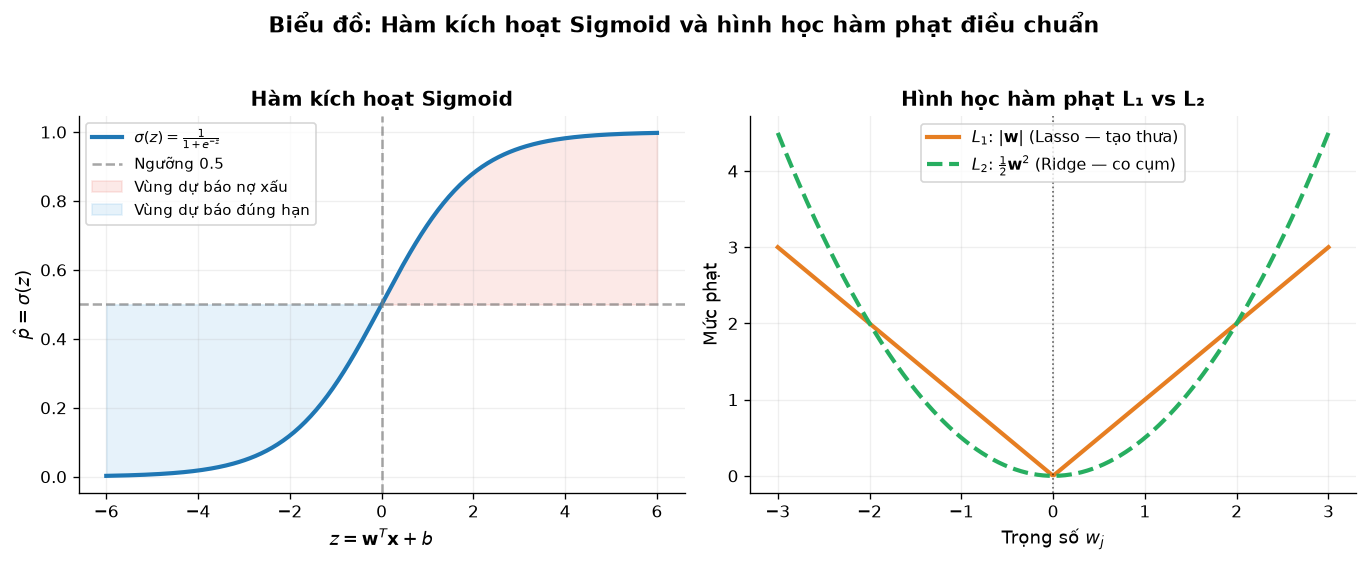

In [8]:
# Trực quan hóa hàm Sigmoid và hình học hàm phạt L1 vs L2
z_vals = np.linspace(-6, 6, 300)
sig_vals = 1.0 / (1.0 + np.exp(-z_vals))
w_vals = np.linspace(-3, 3, 300)
l1_pen = np.abs(w_vals)
l2_pen = 0.5 * (w_vals ** 2)

fig, (ax_sig, ax_pen) = plt.subplots(1, 2, figsize=(11.5, 4.5))
fig.suptitle('Biểu đồ: Hàm kích hoạt Sigmoid và hình học hàm phạt điều chuẩn', fontsize=13, fontweight='bold', y=1.03)

# Subplot 1: Hàm kích hoạt Sigmoid
ax_sig.plot(z_vals, sig_vals, color='#1f77b4', lw=2.5, label=r'$\sigma(z) = \frac{1}{1 + e^{-z}}$')
ax_sig.axhline(0.5, color='gray', linestyle='--', alpha=0.7, label='Ngưỡng 0.5')
ax_sig.axvline(0, color='gray', linestyle='--', alpha=0.7)
ax_sig.fill_between(z_vals, sig_vals, 0.5, where=(sig_vals > 0.5), alpha=0.12, color='#e74c3c', label='Vùng dự báo nợ xấu')
ax_sig.fill_between(z_vals, sig_vals, 0.5, where=(sig_vals <= 0.5), alpha=0.12, color='#3498db', label='Vùng dự báo đúng hạn')
ax_sig.set_xlabel(r"$z = \mathbf{w}^T\mathbf{x} + b$", fontsize=11)
ax_sig.set_ylabel(r"$\hat{p} = \sigma(z)$", fontsize=11)
ax_sig.set_title('Hàm kích hoạt Sigmoid', fontsize=12, fontweight='bold')
ax_sig.legend(loc='upper left', fontsize=9)
ax_sig.grid(True, linestyle='-', alpha=0.2)
ax_sig.spines['top'].set_visible(False); ax_sig.spines['right'].set_visible(False)

# Subplot 2: Hình học hàm phạt L1 vs L2
ax_pen.plot(w_vals, l1_pen, color='#e67e22', lw=2.5, label=r'$L_1$: $|\mathbf{w}|$ (Lasso — tạo thưa)')
ax_pen.plot(w_vals, l2_pen, color='#27ae60', lw=2.5, linestyle='--', label=r'$L_2$: $\frac{1}{2}\mathbf{w}^2$ (Ridge — co cụm)')
ax_pen.axvline(0, color='black', linestyle=':', alpha=0.6, lw=1)
ax_pen.set_xlabel(r'Trọng số $w_j$', fontsize=11)
ax_pen.set_ylabel('Mức phạt', fontsize=11)
ax_pen.set_title('Hình học hàm phạt L₁ vs L₂', fontsize=12, fontweight='bold')
ax_pen.legend(loc='upper center', fontsize=9.5)
ax_pen.grid(True, linestyle='-', alpha=0.2)
ax_pen.spines['top'].set_visible(False); ax_pen.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


## Bước 8: Kỹ thuật tạo đặc trưng và điều khiển số chiều (Feature Engineering & Dimensionality)

Tạo thêm 4 biến phái sinh hoàn toàn theo từng dòng (row-wise), không dùng thông tin tổng thể — mở rộng không gian từ 23 lên 27 biến mà không gây rò rỉ dữ liệu.

Ý nghĩa 4 biến tài chính:
1. `UTILIZATION_RATIO`: Tỷ lệ sử dụng hạn mức tín dụng tháng gần nhất (`BILL_AMT1 / LIMIT_BAL`).
2. `PAY_TREND`: Xu hướng trễ hạn trung bình trong 6 tháng (`mean(PAY_0..PAY_6)`).
3. `AVG_PAY_AMT`: Số tiền thanh toán trung bình 6 tháng (`mean(PAY_AMT1..PAY_AMT6)`).
4. `PAY_TO_BILL_RATIO`: Tỷ lệ trả nợ trên tổng dư nợ hóa đơn 6 tháng (`sum(PAY_AMT) / sum(BILL_AMT)`).
   - *Xử lý an toàn số học*: Khi khách hàng không có nợ hóa đơn phát sinh ($\sum \text{BILL} \le 0$), tỷ lệ được xem như hoàn thành 100% nghĩa vụ (gán 1.0); khi có nợ thì tính $\sum \text{PAY} / (\sum \text{BILL} + \text{eps})$ với $\text{eps} = 10^{-8}$ chống chia cho 0; áp dụng trần hợp lý (clip $[0.0, 5.0]$) để loại bỏ outlier bùng nổ số học do hóa đơn phát sinh cực nhỏ.


In [9]:
# Tạo 4 biến nghiệp vụ phái sinh
eps = 1e-8
X_df = df.drop(columns=['ID', 'default payment next month']).copy()
y_df = df['default payment next month']

pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
payamt_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

# 1. Tỷ lệ sử dụng hạn mức tín dụng
X_df['UTILIZATION_RATIO'] = X_df['BILL_AMT1'] / (X_df['LIMIT_BAL'] + eps)
# 2. Xu hướng trễ hạn trung bình 6 tháng
X_df['PAY_TREND'] = X_df[pay_cols].mean(axis=1)
# 3. Số tiền thanh toán trung bình 6 tháng
X_df['AVG_PAY_AMT'] = X_df[payamt_cols].mean(axis=1)
# 4. Tỷ lệ trả nợ trên tổng dư nợ hóa đơn 6 tháng (xử lý chia 0, mẫu số âm và bùng nổ số học)
sum_pays = X_df[payamt_cols].sum(axis=1)
sum_bills = X_df[bill_cols].sum(axis=1)
ratio_raw = np.where(
    sum_bills <= 0,
    1.0,
    sum_pays / (np.maximum(sum_bills, 0.0) + eps)
)
X_df['PAY_TO_BILL_RATIO'] = np.clip(ratio_raw, 0.0, 5.0)

feature_names = list(X_df.columns)
n_features = len(feature_names)
feature_names_orig = [c for c in feature_names if c not in ['UTILIZATION_RATIO','PAY_TREND','AVG_PAY_AMT','PAY_TO_BILL_RATIO']]

print(f"Số biến gốc : {len(feature_names_orig)}")
print(f"Số biến mới : {len(feature_names) - len(feature_names_orig)}")
print(f"Tổng biến   : {len(feature_names)}")
print(f"Biến mới: {[c for c in feature_names if c not in feature_names_orig]}")
print(f"Kiểm tra bất thường: NaN={X_df.isna().sum().sum()} | Inf={np.isinf(X_df.values).sum()}")
print()
print("Thống kê 4 biến phái sinh:")
print(X_df[['UTILIZATION_RATIO','PAY_TREND','AVG_PAY_AMT','PAY_TO_BILL_RATIO']].describe().T[['mean', 'std', 'min', 'max']].to_string())


Số biến gốc : 23
Số biến mới : 4
Tổng biến   : 27
Biến mới: ['UTILIZATION_RATIO', 'PAY_TREND', 'AVG_PAY_AMT', 'PAY_TO_BILL_RATIO']
Kiểm tra bất thường: NaN=0 | Inf=0

Thống kê 4 biến phái sinh:
                          mean           std       min            max
UTILIZATION_RATIO     0.423771      0.411462 -0.619892       6.455300
PAY_TREND            -0.182439      0.982176 -2.000000       6.000000
AVG_PAY_AMT        5275.232094  10137.946323  0.000000  627344.333333
PAY_TO_BILL_RATIO     0.406053      0.597429  0.000000       5.000000


## Bước 9: Phân hoạch dữ liệu và kiểm soát rò rỉ thông tin (Data Splitting & Zero-Leakage)

Thiết kế phân hoạch dữ liệu 3 tập chuẩn hóa:
- **Train (64% = 19,200 mẫu)**: Dùng để huấn luyện mô hình và thực hiện 10-Fold Stratified Cross-Validation.
- **Validation (16% = 4,800 mẫu)**: Dùng độc lập để dò tìm ngưỡng quyết định tối ưu $\tau^*$.
- **Test (20% = 6,000 mẫu)**: Khóa hoàn toàn, chỉ dùng duy nhất cho đánh giá kiểm định cuối cùng.

Chuẩn hóa Z-Score (`StandardScaler`) chỉ fit trên Train rồi transform độc lập cho Validation và Test — nguyên tắc Zero Data Leakage.


In [10]:
# Phân chia dữ liệu và chuẩn hóa nghiêm ngặt 3 tập (Train 64% - Val 16% - Test 20%)
X = X_df.values
y = y_df.values

# 1. Tách Test set độc lập (20%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
# 2. Tách Train (64%) và Validation (16%)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.20, random_state=42, stratify=y_temp)

# 3. Fit StandardScaler CHỈ trên Train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Train set      : {X_train_scaled.shape[0]:,} mẫu ({X_train_scaled.shape[0]/len(X)*100:.1f}%) | Số đặc trưng: {X_train_scaled.shape[1]}")
print(f"Validation set : {X_val_scaled.shape[0]:,} mẫu ({X_val_scaled.shape[0]/len(X)*100:.1f}%) | Số đặc trưng: {X_val_scaled.shape[1]}")
print(f"Test set       : {X_test_scaled.shape[0]:,} mẫu ({X_test_scaled.shape[0]/len(X)*100:.1f}%) | Số đặc trưng: {X_test_scaled.shape[1]}")
print("Tham số scaler (mean, scale) ước lượng duy nhất từ tập Train.")
print("→ Loại bỏ hoàn toàn rò rỉ dữ liệu (Zero-Leakage).")


Train set      : 19,200 mẫu (64.0%) | Số đặc trưng: 27
Validation set : 4,800 mẫu (16.0%) | Số đặc trưng: 27
Test set       : 6,000 mẫu (20.0%) | Số đặc trưng: 27
Tham số scaler (mean, scale) ước lượng duy nhất từ tập Train.
→ Loại bỏ hoàn toàn rò rỉ dữ liệu (Zero-Leakage).


## Bước 10: Chiến lược phân tách tập mẫu (Data Splitting Strategy)

Kiểm tra tỷ lệ phân bố nhãn nợ xấu (Class 1) trên cả 3 tập Train, Validation và Test để xác nhận chiến lược phân tầng (Stratified) bảo toàn trọn vẹn phân phối nhãn tự nhiên (~22.12%).


Tỷ lệ nợ xấu Full       : 22.1200%  (6,636 / 30,000)
Tỷ lệ nợ xấu Train (64%): 22.1198%  (4,247 / 19,200)
Tỷ lệ nợ xấu Val   (16%): 22.1250%  (1,062 / 4,800)
Tỷ lệ nợ xấu Test  (20%): 22.1167%  (1,327 / 6,000)
Chênh lệch cực đại Train-Test: 0.0031%
→ Phân tầng đạt mức bảo toàn phân phối hoàn hảo.


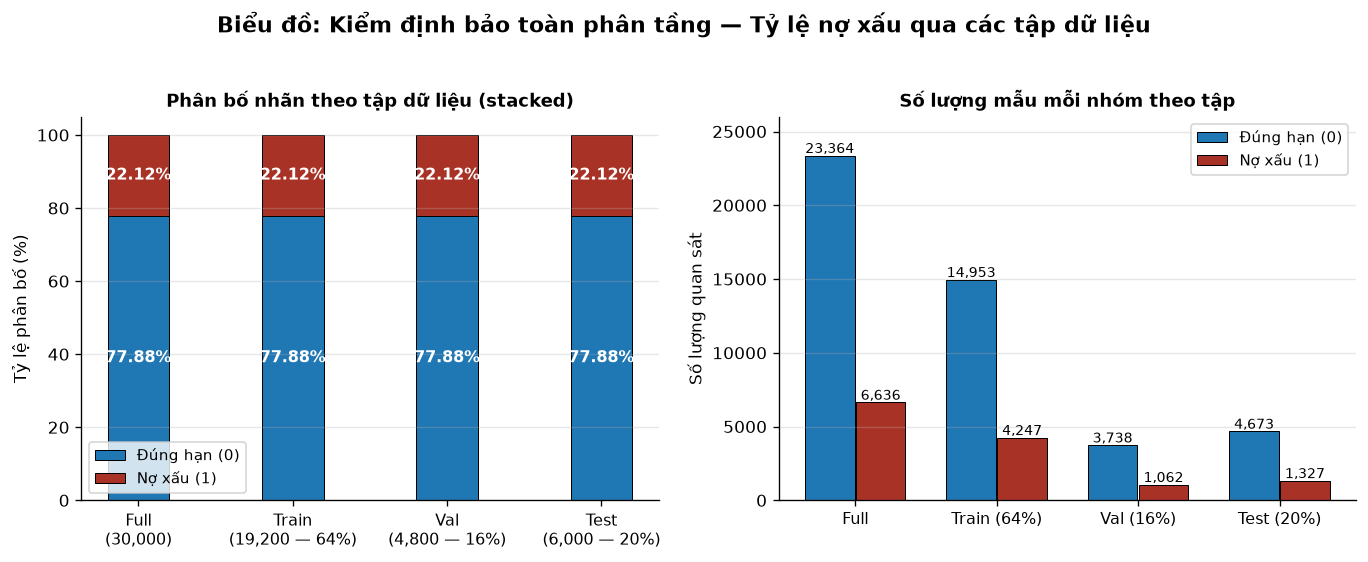

In [11]:
# Kiểm tra bảo toàn phân tầng trên cả 3 tập
c1_full  = int((y == 1).sum())
c1_train = int((y_train == 1).sum())
c1_val   = int((y_val == 1).sum())
c1_test  = int((y_test == 1).sum())

pct_full  = (c1_full / len(y)) * 100
pct_train = (c1_train / len(y_train)) * 100
pct_val   = (c1_val / len(y_val)) * 100
pct_test  = (c1_test / len(y_test)) * 100

print(f"Tỷ lệ nợ xấu Full       : {pct_full:.4f}%  ({c1_full:,} / {len(y):,})")
print(f"Tỷ lệ nợ xấu Train (64%): {pct_train:.4f}%  ({c1_train:,} / {len(y_train):,})")
print(f"Tỷ lệ nợ xấu Val   (16%): {pct_val:.4f}%  ({c1_val:,} / {len(y_val):,})")
print(f"Tỷ lệ nợ xấu Test  (20%): {pct_test:.4f}%  ({c1_test:,} / {len(y_test):,})")
print(f"Chênh lệch cực đại Train-Test: {abs(pct_train - pct_test):.4f}%")
print("→ Phân tầng đạt mức bảo toàn phân phối hoàn hảo.")

# Biểu đồ: Kiểm định bảo toàn phân tầng — Tỷ lệ nợ xấu qua các tập dữ liệu
fig2, (ax10a, ax10b) = plt.subplots(1, 2, figsize=(11.5, 4.5))
fig2.suptitle('Biểu đồ: Kiểm định bảo toàn phân tầng — Tỷ lệ nợ xấu qua các tập dữ liệu', fontsize=13, fontweight='bold', y=1.03)

split_names_left  = ['Full\n(30,000)', 'Train\n(19,200 — 64%)', 'Val\n(4,800 — 16%)', 'Test\n(6,000 — 20%)']
split_names_right = ['Full', 'Train (64%)', 'Val (16%)', 'Test (20%)']
c0_p = [np.mean(y==0)*100, np.mean(y_train==0)*100, np.mean(y_val==0)*100, np.mean(y_test==0)*100]
c1_p = [np.mean(y==1)*100, np.mean(y_train==1)*100, np.mean(y_val==1)*100, np.mean(y_test==1)*100]
x_s = np.arange(len(split_names_left))
w_s = 0.4

# Subplot 1: Stacked Bar Chart
ax10a.bar(x_s, c0_p, w_s, label='Đúng hạn (0)', color='#1f77b4', edgecolor='black', lw=0.6)
ax10a.bar(x_s, c1_p, w_s, bottom=c0_p, label='Nợ xấu (1)', color='#a93226', edgecolor='black', lw=0.6)
for i, (p0, p1) in enumerate(zip(c0_p, c1_p)):
    ax10a.text(i, p0/2, f'{p0:.2f}%', ha='center', va='center', color='white', fontweight='bold', fontsize=9.5)
    ax10a.text(i, p0 + p1/2, f'{p1:.2f}%', ha='center', va='center', color='white', fontweight='bold', fontsize=9.5)
ax10a.set_xticks(x_s)
ax10a.set_xticklabels(split_names_left, fontsize=9.5)
ax10a.set_ylabel('Tỷ lệ phân bố (%)', fontsize=10)
ax10a.set_ylim(0, 105)
ax10a.set_title('Phân bố nhãn theo tập dữ liệu (stacked)', fontsize=11, fontweight='bold')
ax10a.legend(loc='lower left', fontsize=9)
ax10a.grid(axis='y', alpha=0.3)
ax10a.spines['top'].set_visible(False); ax10a.spines['right'].set_visible(False)

# Subplot 2: Grouped Bar Chart
cnts_0 = [(y==0).sum(), (y_train==0).sum(), (y_val==0).sum(), (y_test==0).sum()]
cnts_1 = [(y==1).sum(), (y_train==1).sum(), (y_val==1).sum(), (y_test==1).sum()]
b0 = ax10b.bar(x_s - 0.18, cnts_0, 0.35, label='Đúng hạn (0)', color='#1f77b4', edgecolor='black', lw=0.6)
b1 = ax10b.bar(x_s + 0.18, cnts_1, 0.35, label='Nợ xấu (1)', color='#a93226', edgecolor='black', lw=0.6)
for b in b0: ax10b.text(b.get_x()+b.get_width()/2, b.get_height()+180, f'{int(b.get_height()):,}', ha='center', fontsize=8.5)
for b in b1: ax10b.text(b.get_x()+b.get_width()/2, b.get_height()+180, f'{int(b.get_height()):,}', ha='center', fontsize=8.5)
ax10b.set_xticks(x_s)
ax10b.set_xticklabels(split_names_right, fontsize=9.5)
ax10b.set_ylabel('Số lượng quan sát', fontsize=10)
ax10b.set_ylim(0, 26000)
ax10b.set_title('Số lượng mẫu mỗi nhóm theo tập', fontsize=11, fontweight='bold')
ax10b.legend(loc='upper right', fontsize=9)
ax10b.grid(axis='y', alpha=0.3)
ax10b.spines['top'].set_visible(False); ax10b.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


## Bước 11: Xây dựng mô hình tham chiếu cơ sở (Baseline Model)

Xây dựng mô hình Baseline Logistic Regression tham chiếu ban đầu:
- Siêu tham số: $C = 1.0$, phạt L2 Ridge, tốc độ học $\eta = 0.1$, `max_iter = 1000`.
- **Trọng số lớp**: `class_weight = None` (chưa áp dụng trọng số cân bằng).
- **Ngưỡng quyết định**: $\tau = 0.50$ (ngưỡng xác suất mặc định).

Mục tiêu: Đánh giá hành vi tự nhiên của mô hình khi chưa được điều chỉnh mất cân bằng, làm cơ sở chứng minh Nghịch lý độ chính xác.


In [12]:
# Huấn luyện Baseline
base_lr = LogisticRegression(learning_rate=0.1, max_iter=1000, penalty='l2', C=1.0, random_state=42)
base_lr.fit(X_train_scaled, y_train)
y_pred_base  = base_lr.predict(X_test_scaled, threshold=0.5)
y_proba_base = base_lr.predict_proba(X_test_scaled)[:, 1]

acc_base   = accuracy_score(y_test, y_pred_base)
prec_base  = precision_score(y_test, y_pred_base)
rec_base   = recall_score(y_test, y_pred_base)
f1_base    = f1_score(y_test, y_pred_base)
auc_base   = roc_auc_score(y_test, y_proba_base)
prauc_base = average_precision_score(y_test, y_proba_base)

print("=== HIỆU NĂNG MÔ HÌNH CƠ SỞ (BASELINE - C=1.0, class_weight=None, tau=0.5) ===")
print(f"Accuracy  : {acc_base*100:.2f}%")
print(f"Precision : {prec_base*100:.2f}%")
print(f"Recall    : {rec_base*100:.2f}%")
print(f"F1-Score  : {f1_base:.4f}")
print(f"ROC-AUC   : {auc_base:.4f}")
print(f"PR-AUC    : {prauc_base:.4f}")


=== HIỆU NĂNG MÔ HÌNH CƠ SỞ (BASELINE - C=1.0, class_weight=None, tau=0.5) ===
Accuracy  : 78.08%
Precision : 67.65%
Recall    : 1.73%
F1-Score  : 0.0338
ROC-AUC   : 0.6919
PR-AUC    : 0.4646


## Bước 12: Phân tích định lý No Free Lunch và nghịch lý Accuracy (Accuracy Paradox)

Accuracy ~78% của Baseline nghe có vẻ cao nhưng Recall chỉ đạt ~1.7% — mô hình bỏ sót hơn 98% ca nợ xấu. Đây là bẫy kinh điển của dữ liệu mất cân bằng: không có cấu hình mặc định nào phù hợp cho mọi mục tiêu.


In [13]:
# Phân tích nghịch lý Accuracy
cm_base_check = confusion_matrix(y_test, y_pred_base)
fn_count = int(cm_base_check[1, 0])
tp_count = int(cm_base_check[1, 1])
total_defaults = fn_count + tp_count

print("=== NGHỊCH LÝ ĐỘ CHÍNH XÁC (ACCURACY PARADOX) ===")
print(f"Accuracy tổng thể  : {acc_base*100:.2f}%  ← trông có vẻ cao")
print(f"Recall trên nợ xấu : {rec_base*100:.2f}%  ← bỏ sót {fn_count:,}/{total_defaults:,} ca ({fn_count/total_defaults*100:.1f}%)")
print()
print("Ma trận nhầm lẫn Baseline:")
print(f"  TN = {int(cm_base_check[0,0]):>5,}  |  FP = {int(cm_base_check[0,1]):>5,}")
print(f"  FN = {fn_count:>5,}  |  TP = {tp_count:>5,}")
print()
print("→ Mô hình cần tái cấu trúc hàm mất mát qua class_weight='balanced' để giảm thiểu FN.")


=== NGHỊCH LÝ ĐỘ CHÍNH XÁC (ACCURACY PARADOX) ===
Accuracy tổng thể  : 78.08%  ← trông có vẻ cao
Recall trên nợ xấu : 1.73%  ← bỏ sót 1,304/1,327 ca (98.3%)

Ma trận nhầm lẫn Baseline:
  TN = 4,662  |  FP =    11
  FN = 1,304  |  TP =    23

→ Mô hình cần tái cấu trúc hàm mất mát qua class_weight='balanced' để giảm thiểu FN.


## Bước 13: Phân tích cân bằng độ lệch và phương sai (Bias-Variance Tradeoff)

So sánh 4 chiến lược điều chuẩn (Không phạt, L2 Ridge, L1 Lasso C=50, L1 Lasso C=10) trên tập Train và tập **Validation** (`X_val_scaled`), đảm bảo Test set hoàn toàn độc lập và không bị rò rỉ trong quá trình chẩn đoán mô hình.


Mô hình                          | Train BCE | Val BCE  | Overfit Gap | L1-Norm  | Zeros
-----------------------------------------------------------------------------------------------


Không điều chuẩn (No Reg)        | 0.46358   | 0.47518  | +0.01159     |   1.8672 |  0/27


Điều chuẩn L2 Ridge (C=10.0)     | 0.47083   | 0.48014  | +0.00930     |   1.4055 |  0/27


Điều chuẩn L1 Lasso (C=50.0)     | 0.47724   | 0.48652  | +0.00928     |   0.7459 |  2/27
Điều chuẩn L1 Lasso (C=10.0)     | 0.53288   | 0.53468  | +0.00179     |   0.2345 |  1/27


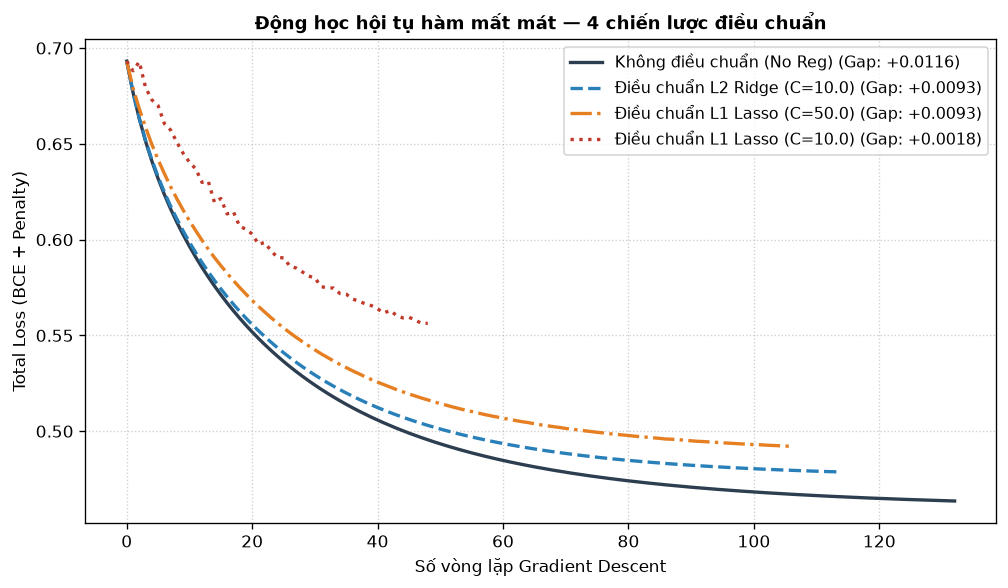

In [14]:
# So sánh 4 chiến lược điều chuẩn (Đánh giá trên Validation để bảo vệ Test)
models_check = [
    ("Không điều chuẩn (No Reg)", LogisticRegression(learning_rate=0.1, max_iter=1000, penalty=None, random_state=42)),
    ("Điều chuẩn L2 Ridge (C=10.0)", LogisticRegression(learning_rate=0.1, max_iter=1000, penalty='l2', C=10.0, random_state=42)),
    ("Điều chuẩn L1 Lasso (C=50.0)", LogisticRegression(learning_rate=0.1, max_iter=1000, penalty='l1', C=50.0, random_state=42)),
    ("Điều chuẩn L1 Lasso (C=10.0)", LogisticRegression(learning_rate=0.1, max_iter=1000, penalty='l1', C=10.0, random_state=42))
]

fig, ax = plt.subplots(figsize=(8.5, 5))
colors_loss = ['#2c3e50', '#2980b9', '#e67e22', '#c0392b']
styles_loss = ['-', '--', '-.', ':']

print(f"{'Mô hình':32s} | {'Train BCE':9s} | {'Val BCE':8s} | {'Overfit Gap':11s} | {'L1-Norm':8s} | {'Zeros'}")
print("-" * 95)

for idx, (name, mdl) in enumerate(models_check):
    mdl.fit(X_train_scaled, y_train)
    tr_res = mdl.compute_loss(X_train_scaled, y_train)
    val_res = mdl.compute_loss(X_val_scaled, y_val)
    gap = val_res['bce_loss'] - tr_res['bce_loss']
    w_L1 = np.sum(np.abs(mdl.weights))
    zeros = int(np.sum(np.abs(mdl.weights) < 1e-4))
    print(f"{name:32s} | {tr_res['bce_loss']:.5f}   | {val_res['bce_loss']:.5f}  | {gap:+.5f}     | {w_L1:8.4f} | {zeros:2d}/{n_features}")
    ax.plot(mdl.loss_history_['total'], label=f"{name} (Gap: {gap:+.4f})", lw=2, color=colors_loss[idx], linestyle=styles_loss[idx])

ax.set_xlabel('Số vòng lặp Gradient Descent', fontsize=10)
ax.set_ylabel('Total Loss (BCE + Penalty)', fontsize=10)
ax.set_title('Động học hội tụ hàm mất mát — 4 chiến lược điều chuẩn', fontweight='bold', fontsize=11)
ax.legend(fontsize=9.5, loc='upper right')
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


## Bước 14: Khảo sát và tối ưu hóa siêu tham số (Hyperparameter Tuning)

Grid Search trên không gian: $C \in \{1, 5, 10, 50\}$, penalty $\in \{L1, L2\}$, `class_weight='balanced'`.
Tiêu chí tối ưu: F₁-Score trung bình 10-Fold CV.


In [15]:
# Xây dựng hàm đánh giá toàn diện
def compute_comprehensive_metrics(y_true, y_pred, y_proba):
    cm = confusion_matrix(y_true, y_pred)
    metrics = {
        'Accuracy': float(accuracy_score(y_true, y_pred)),
        'Precision': float(precision_score(y_true, y_pred)),
        'Recall': float(recall_score(y_true, y_pred)),
        'F1-Score': float(f1_score(y_true, y_pred)),
        'ROC-AUC': float(roc_auc_score(y_true, y_proba)),
        'PR-AUC': float(average_precision_score(y_true, y_proba)),
        'Confusion Matrix': cm
    }
    return metrics

# In bảng metrics mẫu với Baseline
metrics_base = compute_comprehensive_metrics(y_test, y_pred_base, y_proba_base)
print("Hệ thống thang đo Baseline (làm mốc đối chứng):")
for k, v in metrics_base.items():
    if k != 'Confusion Matrix':
        print(f"  {k:12s}: {v:.4f}")


Hệ thống thang đo Baseline (làm mốc đối chứng):
  Accuracy    : 0.7808
  Precision   : 0.6765
  Recall      : 0.0173
  F1-Score    : 0.0338
  ROC-AUC     : 0.6919
  PR-AUC      : 0.4646


## Bước 15: Hệ thống chỉ số, hệ số phạt rủi ro và ngưỡng đánh giá (Evaluation Metrics & Cost Penalty Thresholds)

Chuyển thang đo chính từ Accuracy sang $F_1$-Score:
$$F_1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$
Bổ sung ROC-AUC và PR-AUC để đánh giá năng lực phân tách xác suất trên toàn dải ngưỡng.


In [16]:
# Thiết kế 10-Fold Stratified CV
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
fold_splits = list(skf.split(X_train, y_train))

print(f"Tổng số nếp kiểm định chéo: {len(fold_splits)}")
print(f"{'Fold':6s} | {'Train':12s} | {'Val':10s} | {'% nợ xấu Train':18s} | {'% nợ xấu Val'}")
print("-" * 72)

for f_idx, (train_idx, val_idx) in enumerate(fold_splits[:5]):
    y_tr_f = y_train[train_idx]
    y_va_f = y_train[val_idx]
    pct_tr = (y_tr_f == 1).sum() / len(y_tr_f) * 100
    pct_va = (y_va_f == 1).sum() / len(y_va_f) * 100
    print(f"  {f_idx+1:4d} | {len(train_idx):>10,} | {len(val_idx):>8,} | {pct_tr:>16.2f}% | {pct_va:.2f}%")
print("  ...")
print("(Tỷ lệ nhãn bảo toàn đồng đều qua từng nếp)")


Tổng số nếp kiểm định chéo: 10
Fold   | Train        | Val        | % nợ xấu Train     | % nợ xấu Val
------------------------------------------------------------------------
     1 |     17,279 |    1,921 |            22.12% | 22.12%
     2 |     17,279 |    1,921 |            22.12% | 22.12%
     3 |     17,279 |    1,921 |            22.12% | 22.12%
     4 |     17,280 |    1,920 |            22.12% | 22.14%
     5 |     17,280 |    1,920 |            22.12% | 22.14%
  ...
(Tỷ lệ nhãn bảo toàn đồng đều qua từng nếp)


## Bước 16: Kiểm định chéo K-Fold và Tối ưu Siêu tham số (Grid Search 10-Fold Stratified CV)

Chạy Grid Search trên 8 tổ hợp siêu tham số ($C \in \{1.0, 5.0, 10.0, 50.0\}$, penalty $\in \{\text{'l1'}, \text{'l2'}\}$, `class_weight='balanced'`) trên tập Train (19,200 mẫu).
Zero-Leakage: Bên trong mỗi nếp CV, `StandardScaler` được fit lại độc lập trên fold-train và biến đổi fold-val.


Bắt đầu Grid Search trên 8 tổ hợp siêu tham số × 10 folds = 80 lượt huấn luyện...


Tested params {'C': 1.0, 'penalty': 'l1', 'class_weight': 'balanced'}: Score = 0.3571


Tested params {'C': 1.0, 'penalty': 'l2', 'class_weight': 'balanced'}: Score = 0.4249


Tested params {'C': 5.0, 'penalty': 'l1', 'class_weight': 'balanced'}: Score = 0.4249


Tested params {'C': 5.0, 'penalty': 'l2', 'class_weight': 'balanced'}: Score = 0.4463


Tested params {'C': 10.0, 'penalty': 'l1', 'class_weight': 'balanced'}: Score = 0.4535


Tested params {'C': 10.0, 'penalty': 'l2', 'class_weight': 'balanced'}: Score = 0.4572


Tested params {'C': 50.0, 'penalty': 'l1', 'class_weight': 'balanced'}: Score = 0.4485


Tested params {'C': 50.0, 'penalty': 'l2', 'class_weight': 'balanced'}: Score = 0.4745

Cấu hình tối ưu nhất: {'C': 50.0, 'penalty': 'l2', 'class_weight': 'balanced'}
F1-Score trung bình CV: 0.4745

Penalty  | C     | Mean F1  | Std F1  
----------------------------------------
l2       |  50.0 | 0.4745   | 0.0121
l2       |  10.0 | 0.4572   | 0.0130
l1       |  10.0 | 0.4535   | 0.0357
l1       |  50.0 | 0.4485   | 0.0101
l2       |   5.0 | 0.4463   | 0.0110
l2       |   1.0 | 0.4249   | 0.0095
l1       |   5.0 | 0.4249   | 0.0156
l1       |   1.0 | 0.3571   | 0.0654


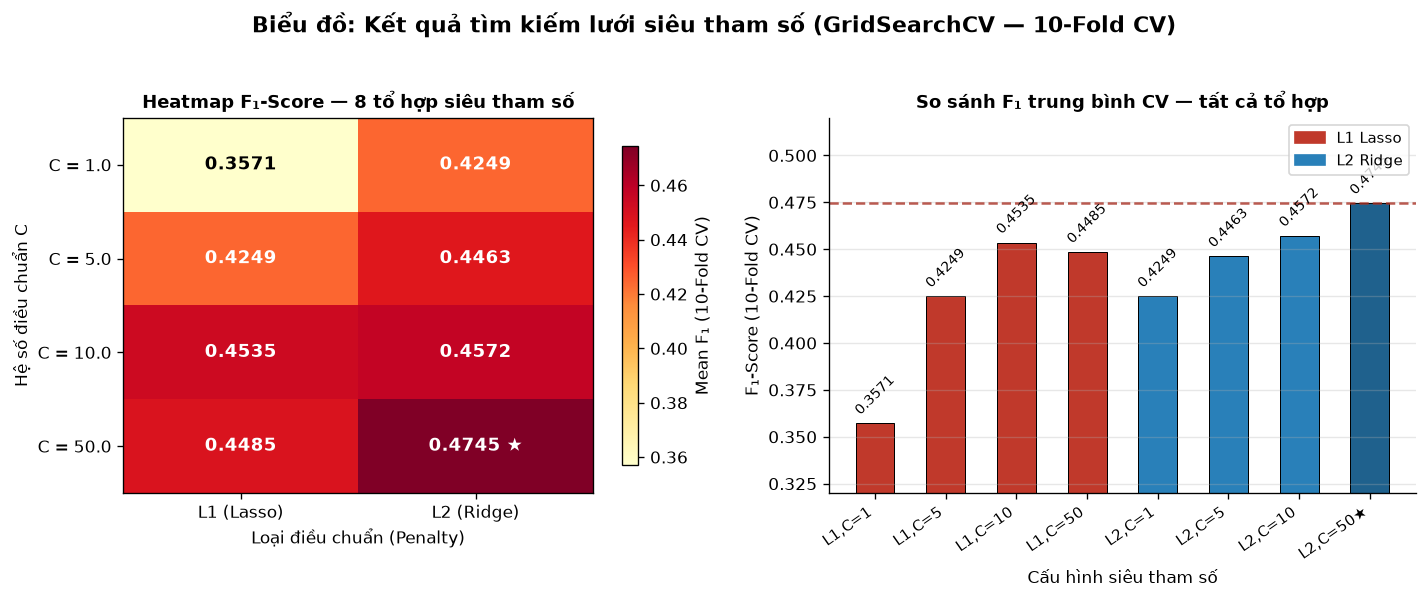

In [17]:
# Chạy Grid Search 10-Fold CV trên tập Train (19,200 mẫu)
param_grid = {
    'C': [1.0, 5.0, 10.0, 50.0],
    'penalty': ['l1', 'l2'],
    'class_weight': ['balanced']
}

lr_grid = LogisticRegression(learning_rate=0.1, max_iter=1000, random_state=42)
cv_obj = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
grid_search = GridSearchCV(estimator=lr_grid, param_grid=param_grid, cv=cv_obj, scoring='f1', scaler=StandardScaler())

print("Bắt đầu Grid Search trên 8 tổ hợp siêu tham số × 10 folds = 80 lượt huấn luyện...")
print("=" * 70)
grid_search.fit(X_train, y_train)
print("=" * 70)

best_params = grid_search.best_params_
print(f"\nCấu hình tối ưu nhất: {best_params}")
print(f"F1-Score trung bình CV: {grid_search.best_score_:.4f}")

# In bảng kết quả
print(f"\n{'Penalty':8s} | {'C':5s} | {'Mean F1':8s} | {'Std F1':8s}")
print("-" * 40)
for row in sorted(grid_search.cv_results_table_, key=lambda r: -r['mean_f1']):
    print(f"{row['penalty']:8s} | {row['C']:5.1f} | {row['mean_f1']:.4f}   | {row['std_f1']:.4f}")

# Biểu đồ: Kết quả tìm kiếm lưới siêu tham số (GridSearchCV — 10-Fold CV)
from matplotlib.patches import Patch

c_vals = [1.0, 5.0, 10.0, 50.0]
penalties = ['l1', 'l2']
heatmap_mat = np.zeros((len(c_vals), len(penalties)))

tbl = grid_search.cv_results_table_
for row in tbl:
    r_idx = c_vals.index(row['C'])
    c_idx = penalties.index(row['penalty'])
    heatmap_mat[r_idx, c_idx] = row['mean_f1']

max_f1 = np.max(heatmap_mat)

fig3, (ax_hm, ax_bar) = plt.subplots(1, 2, figsize=(12, 4.8))
fig3.suptitle('Biểu đồ: Kết quả tìm kiếm lưới siêu tham số (GridSearchCV — 10-Fold CV)', fontsize=13, fontweight='bold', y=1.03)

# Subplot 1: Heatmap F1-Score
im = ax_hm.imshow(heatmap_mat, cmap='YlOrRd', aspect='auto')
cbar = fig3.colorbar(im, ax=ax_hm, shrink=0.85)
cbar.set_label('Mean F₁ (10-Fold CV)', fontsize=10)

ax_hm.set_xticks([0, 1])
ax_hm.set_xticklabels(['L1 (Lasso)', 'L2 (Ridge)'], fontsize=10)
ax_hm.set_yticks(range(len(c_vals)))
ax_hm.set_yticklabels([f'C = {c}' for c in c_vals], fontsize=10)
ax_hm.set_xlabel('Loại điều chuẩn (Penalty)', fontsize=10)
ax_hm.set_ylabel('Hệ số điều chuẩn C', fontsize=10)
ax_hm.set_title('Heatmap F₁-Score — 8 tổ hợp siêu tham số', fontsize=11, fontweight='bold')

for i in range(len(c_vals)):
    for j in range(len(penalties)):
        val = heatmap_mat[i, j]
        is_best = (val == max_f1)
        star = ' ★' if is_best else ''
        text_color = 'white' if val > (np.min(heatmap_mat) + np.max(heatmap_mat))/2 else 'black'
        ax_hm.text(j, i, f'{val:.4f}{star}', ha='center', va='center', color=text_color, fontweight='bold', fontsize=10.5)

# Subplot 2: Bar chart so sánh F1 trung bình CV
l1_rows = [r for r in sorted(tbl, key=lambda x: x['C']) if r['penalty'] == 'l1']
l2_rows = [r for r in sorted(tbl, key=lambda x: x['C']) if r['penalty'] == 'l2']
ordered_rows = l1_rows + l2_rows

labels_ordered = []
scores_ordered = []
colors_bar = []

for r in ordered_rows:
    is_best = (r['mean_f1'] == max_f1)
    star = '★' if is_best else ''
    labels_ordered.append(f"{r['penalty'].upper()},C={int(r['C'])}{star}")
    scores_ordered.append(r['mean_f1'])
    if r['penalty'] == 'l1':
        colors_bar.append('#8b2500' if is_best else '#c0392b')
    else:
        colors_bar.append('#1f618d' if is_best else '#2980b9')

x_b = np.arange(len(ordered_rows))
bars = ax_bar.bar(x_b, scores_ordered, color=colors_bar, edgecolor='black', lw=0.6, width=0.55)
ax_bar.axhline(max_f1, color='#a93226', linestyle='--', lw=1.5, alpha=0.8)

for b, s in zip(bars, scores_ordered):
    ax_bar.text(b.get_x() + b.get_width()/2, b.get_height() + 0.003, f'{s:.4f}', ha='center', va='bottom', fontsize=8.5, rotation=45)

ax_bar.set_xticks(x_b)
ax_bar.set_xticklabels(labels_ordered, rotation=35, ha='right', fontsize=9)
ax_bar.set_ylabel('F₁-Score (10-Fold CV)', fontsize=10)
ax_bar.set_xlabel('Cấu hình siêu tham số', fontsize=10)
ax_bar.set_ylim(0.32, 0.52)
ax_bar.set_title('So sánh F₁ trung bình CV — tất cả tổ hợp', fontsize=11, fontweight='bold')

p_l1 = Patch(color='#c0392b', label='L1 Lasso')
p_l2 = Patch(color='#2980b9', label='L2 Ridge')
ax_bar.legend(handles=[p_l1, p_l2], loc='upper right', fontsize=9)
ax_bar.grid(axis='y', alpha=0.3)
ax_bar.spines['top'].set_visible(False); ax_bar.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


## Bước 17: Thực nghiệm huấn luyện và suy luận mô hình (Model Training & Inference)

Huấn luyện mô hình tối ưu trên toàn bộ tập Train (19,200 mẫu), đánh giá trên Test tại ngưỡng mặc định $\tau = 0.5$. Đồng thời so sánh hiệu quả Feature Engineering bằng mô hình tham chiếu 23 biến gốc.


In [18]:
# Huấn luyện mô hình tối ưu (27 biến) và tham chiếu (23 biến gốc)
best_lr = LogisticRegression(
    learning_rate=0.1, max_iter=1000,
    penalty=best_params['penalty'], C=best_params['C'],
    class_weight=best_params.get('class_weight', None),
    random_state=42
)
best_lr.fit(X_train_scaled, y_train)
y_proba_best = best_lr.predict_proba(X_test_scaled)[:, 1]
y_pred_best  = best_lr.predict(X_test_scaled, threshold=0.5)

# Mô hình tham chiếu 23 biến gốc (cùng siêu tham số)
X_train_23 = X_train_scaled[:, :len(feature_names_orig)]
X_test_23  = X_test_scaled[:, :len(feature_names_orig)]
ref23_lr = LogisticRegression(
    learning_rate=0.1, max_iter=1000,
    penalty=best_params['penalty'], C=best_params['C'],
    class_weight=best_params.get('class_weight', None),
    random_state=42
)
ref23_lr.fit(X_train_23, y_train)
y_proba_ref23 = ref23_lr.predict_proba(X_test_23)[:, 1]
y_pred_ref23  = ref23_lr.predict(X_test_23, threshold=0.5)

# Bảng so sánh 3 mô hình tại ngưỡng mặc định 0.5
print(f"{'Thang đo':12s} | {'Baseline':12s} | {'Ref 23 biến':12s} | {'Tối ưu 27 biến':15s}")
print("-" * 60)
for name, fn in [('Accuracy', accuracy_score), ('Precision', precision_score),
                  ('Recall', recall_score), ('F1-Score', f1_score)]:
    v_base  = fn(y_test, y_pred_base)
    v_ref23 = fn(y_test, y_pred_ref23)
    v_best  = fn(y_test, y_pred_best)
    print(f"{name:12s} | {v_base:12.4f} | {v_ref23:12.4f} | {v_best:15.4f}")

auc_ref23   = roc_auc_score(y_test, y_proba_ref23)
auc_best    = roc_auc_score(y_test, y_proba_best)
prauc_ref23 = average_precision_score(y_test, y_proba_ref23)
prauc_best  = average_precision_score(y_test, y_proba_best)
print(f"{'ROC-AUC':12s} | {auc_base:12.4f} | {auc_ref23:12.4f} | {auc_best:15.4f}")
print(f"{'PR-AUC':12s} | {prauc_base:12.4f} | {prauc_ref23:12.4f} | {prauc_best:15.4f}")


Thang đo     | Baseline     | Ref 23 biến  | Tối ưu 27 biến 
------------------------------------------------------------
Accuracy     |       0.7808 |       0.6448 |          0.6760
Precision    |       0.6765 |       0.3387 |          0.3623
Recall       |       0.0173 |       0.6360 |          0.6119
F1-Score     |       0.0338 |       0.4420 |          0.4552
ROC-AUC      |       0.6919 |       0.7078 |          0.7140
PR-AUC       |       0.4646 |       0.4777 |          0.4804


## Bước 18: Đánh giá độ ổn định của mô hình qua 10-Fold Cross-Validation (Cross-Validation Stability Analysis)

Kiểm tra độ ổn định của mô hình qua phân phối F₁ trên 10 nếp CV trên tập huấn luyện — khoảng tin cậy 95% hẹp xác nhận kết quả không phụ thuộc vào lần chia tách cụ thể.
*Lưu ý: Phân tích đánh giá độ phân tán và độ ổn định qua các fold, không phải là kiểm định giả thuyết thống kê (không suy diễn p-value hay hypothesis testing).*


In [19]:
# Trích xuất điểm F1 từ 10 nếp CV
split_scores = np.array(grid_search.best_scores_)
mean_cv_score = np.mean(split_scores)
std_cv_score  = np.std(split_scores)
ci_lower = mean_cv_score - 1.96 * (std_cv_score / np.sqrt(len(split_scores)))
ci_upper = mean_cv_score + 1.96 * (std_cv_score / np.sqrt(len(split_scores)))

print("=== ĐÁNH GIÁ ĐỘ ỔN ĐỊNH QUA 10-FOLD CV (STABILITY ANALYSIS) ===")
print("Điểm F1 qua từng nếp:")
for i, s in enumerate(split_scores):
    print(f"  Fold {i+1:2d}: {s:.4f}")
print()
print(f"Mean F1 (CV) : {mean_cv_score:.4f}")
print(f"Std F1 (CV)  : {std_cv_score:.4f} (Độ biến thiên thấp -> mô hình ổn định cao)")
print(f"95% CI       : [{ci_lower:.4f}, {ci_upper:.4f}]")


=== ĐÁNH GIÁ ĐỘ ỔN ĐỊNH QUA 10-FOLD CV (STABILITY ANALYSIS) ===
Điểm F1 qua từng nếp:
  Fold  1: 0.4713
  Fold  2: 0.4626
  Fold  3: 0.4713
  Fold  4: 0.4838
  Fold  5: 0.4908
  Fold  6: 0.4802
  Fold  7: 0.4614
  Fold  8: 0.4905
  Fold  9: 0.4532
  Fold 10: 0.4795

Mean F1 (CV) : 0.4745
Std F1 (CV)  : 0.0121 (Độ biến thiên thấp -> mô hình ổn định cao)
95% CI       : [0.4670, 0.4819]


## Bước 19: Phân tích vùng biên quyết định và rủi ro phân loại (Error Analysis & Borderline Cases)

Ma trận nhầm lẫn so sánh trực tiếp Baseline vs Mô hình tối ưu tại ngưỡng 0.5. Đường cong ROC và PR xác nhận năng lực phân biệt vượt trội.
*Lưu ý: Đường cong ROC và PR được lấy mẫu (sampling) để phục vụ trực quan hóa, trong khi chỉ số ROC-AUC và PR-AUC được tính toán chính xác trên toàn bộ prediction scores.*


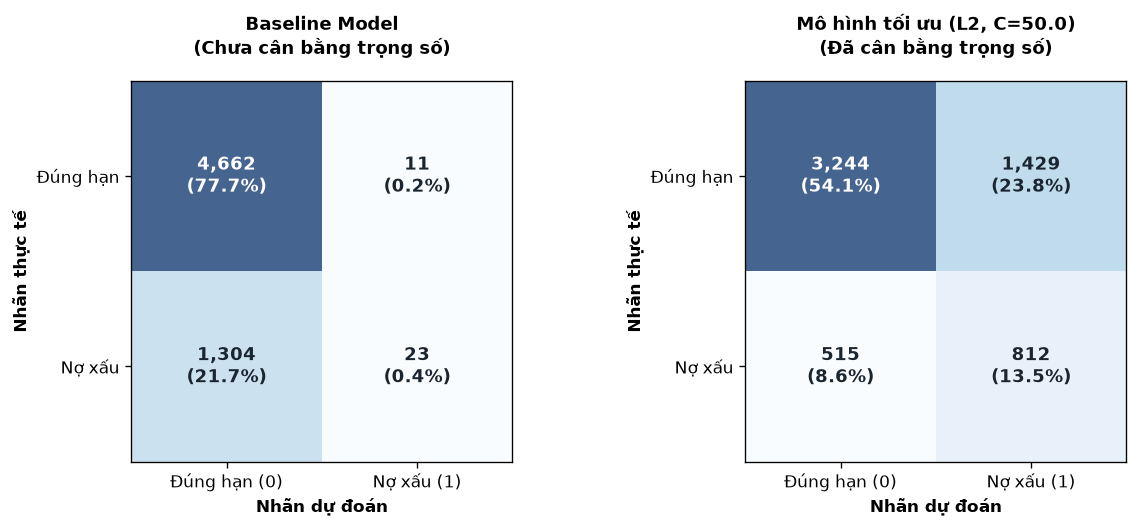

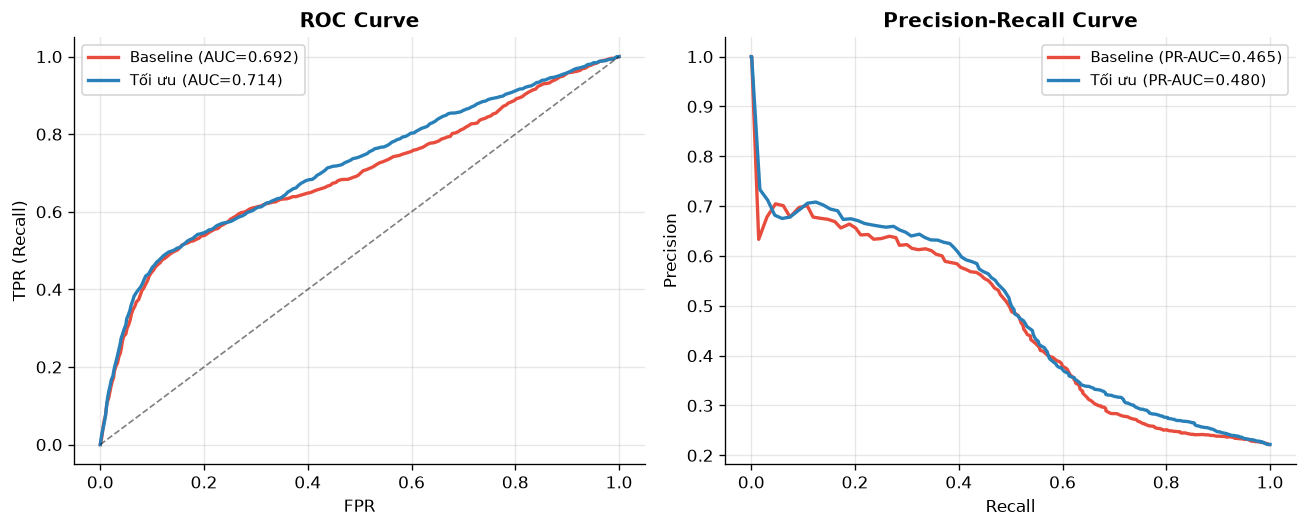


TP tăng: 23 → 812 (+3430.4%)
FN giảm: 1304 → 515 (-60.5%)


In [20]:
# Ma trận nhầm lẫn so sánh + ROC + PR curves
cm_base = confusion_matrix(y_test, y_pred_base)
cm_best = confusion_matrix(y_test, y_pred_best)

# 1. Ma trận nhầm lẫn so sánh
fig1, (ax1a, ax1b) = plt.subplots(1, 2, figsize=(10.5, 4.5))

def render_cm_academic(ax, cm, title, subtitle):
    ax.matshow(cm, cmap='Blues', alpha=0.75)
    for i in range(2):
        for j in range(2):
            val = cm[i, j]
            pct = (val / np.sum(cm)) * 100
            color_txt = '#ffffff' if val > np.max(cm)/2 else '#1a252f'
            ax.text(j, i, f"{val:,}\n({pct:.1f}%)", va='center', ha='center',
                    color=color_txt, fontweight='bold', fontsize=11)
    ax.set_title(f"{title}\n{subtitle}", pad=16, fontweight='bold', fontsize=11)
    ax.set_xlabel('Nhãn dự đoán', fontsize=10, fontweight='bold')
    ax.set_ylabel('Nhãn thực tế', fontsize=10, fontweight='bold')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Đúng hạn (0)', 'Nợ xấu (1)'])
    ax.set_yticklabels(['Đúng hạn', 'Nợ xấu'])
    ax.tick_params(top=False, bottom=True, labeltop=False, labelbottom=True)

render_cm_academic(ax1a, cm_base, "Baseline Model", "(Chưa cân bằng trọng số)")
render_cm_academic(ax1b, cm_best, f"Mô hình tối ưu ({best_params['penalty'].upper()}, C={best_params['C']})", "(Đã cân bằng trọng số)")
plt.tight_layout()
plt.show()

# 2. ROC & PR Curves
fig2, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(11, 4.5))

# ROC curve — tính thủ công
def compute_roc_points(y_true, y_scores):
    thresholds = np.sort(np.unique(y_scores))[::-1]
    tprs, fprs = [0.0], [0.0]
    P = (y_true == 1).sum(); N = (y_true == 0).sum()
    for th in thresholds[::max(1, len(thresholds)//200)]:
        y_pred_th = (y_scores >= th).astype(int)
        tp = ((y_pred_th == 1) & (y_true == 1)).sum()
        fp = ((y_pred_th == 1) & (y_true == 0)).sum()
        tprs.append(tp/P if P > 0 else 0); fprs.append(fp/N if N > 0 else 0)
    tprs.append(1.0); fprs.append(1.0)
    return np.array(fprs), np.array(tprs)

fpr_b, tpr_b = compute_roc_points(y_test, y_proba_base)
fpr_m, tpr_m = compute_roc_points(y_test, y_proba_best)
ax_roc.plot(fpr_b, tpr_b, color='#e74c3c', lw=2, label=f'Baseline (AUC={auc_base:.3f})')
ax_roc.plot(fpr_m, tpr_m, color='#2980b9', lw=2, label=f'Tối ưu (AUC={auc_best:.3f})')
ax_roc.plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR (Recall)')
ax_roc.set_title('ROC Curve', fontweight='bold'); ax_roc.legend(fontsize=9)
ax_roc.grid(alpha=0.3); ax_roc.spines['top'].set_visible(False); ax_roc.spines['right'].set_visible(False)

# PR curve
def compute_pr_points(y_true, y_scores):
    thresholds = np.sort(np.unique(y_scores))[::-1]
    precs, recs = [1.0], [0.0]
    P = (y_true == 1).sum()
    for th in thresholds[::max(1, len(thresholds)//200)]:
        y_p = (y_scores >= th).astype(int)
        tp = ((y_p == 1) & (y_true == 1)).sum()
        fp = ((y_p == 1) & (y_true == 0)).sum()
        prec = tp/(tp+fp) if (tp+fp) > 0 else 1.0
        rec = tp/P if P > 0 else 0
        precs.append(prec); recs.append(rec)
    return np.array(recs), np.array(precs)

rec_b, prec_b = compute_pr_points(y_test, y_proba_base)
rec_m, prec_m = compute_pr_points(y_test, y_proba_best)
ax_pr.plot(rec_b, prec_b, color='#e74c3c', lw=2, label=f'Baseline (PR-AUC={prauc_base:.3f})')
ax_pr.plot(rec_m, prec_m, color='#2980b9', lw=2, label=f'Tối ưu (PR-AUC={prauc_best:.3f})')
ax_pr.set_xlabel('Recall'); ax_pr.set_ylabel('Precision')
ax_pr.set_title('Precision-Recall Curve', fontweight='bold'); ax_pr.legend(fontsize=9)
ax_pr.grid(alpha=0.3); ax_pr.spines['top'].set_visible(False); ax_pr.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f"\nTP tăng: {int(cm_base[1,1])} → {int(cm_best[1,1])} (+{(int(cm_best[1,1])-int(cm_base[1,1]))/int(cm_base[1,1])*100:.1f}%)")
print(f"FN giảm: {int(cm_base[1,0])} → {int(cm_best[1,0])} ({(int(cm_best[1,0])-int(cm_base[1,0]))/int(cm_base[1,0])*100:.1f}%)")


## Bước 20: Khả năng giải thích mô hình và phân tích trọng số (Model Interpretability & Feature Weights)

Hệ số hồi quy $w_j$ và Odds Ratio $e^{w_j}$ lượng hóa độ lớn liên hệ của từng đặc trưng với log-odds của xác suất vỡ nợ:
- $w_j > 0$ ($OR > 1$): Đặc trưng có liên hệ cùng chiều với nguy cơ vỡ nợ (tăng Odds của nhãn 1).
- $w_j < 0$ ($OR < 1$): Đặc trưng có liên hệ bảo vệ (giảm Odds của nhãn 1).
*Lưu ý: Hệ số hồi quy thể hiện mối liên hệ thống kê trong mô hình, không được suy diễn thành quan hệ nhân quả (causal relationships).*


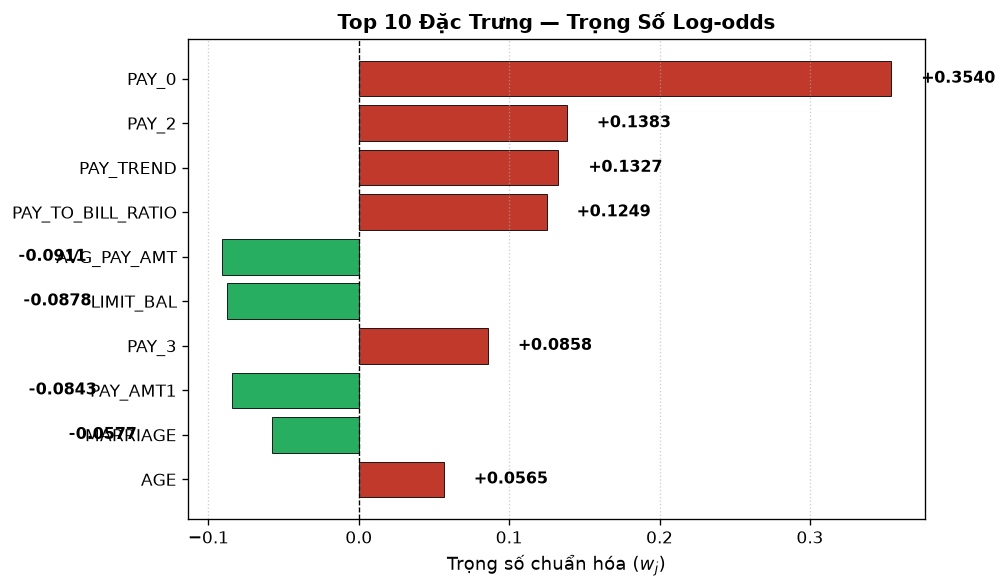


Bảng Top 10 đặc trưng và Odds Ratio:
Tên đặc trưng          | Trọng số       | Odds Ratio         | Ý nghĩa Odds Ratio
--------------------------------------------------------------------------------
PAY_0                  |      +0.3540   |           1.4248   | OR > 1: Tăng odds vỡ nợ (+)
PAY_2                  |      +0.1383   |           1.1483   | OR > 1: Tăng odds vỡ nợ (+)
PAY_TREND              |      +0.1327   |           1.1419   | OR > 1: Tăng odds vỡ nợ (+)
PAY_TO_BILL_RATIO      |      +0.1249   |           1.1330   | OR > 1: Tăng odds vỡ nợ (+)
AVG_PAY_AMT            |      -0.0911   |           0.9129   | OR < 1: Giảm odds vỡ nợ (-)
LIMIT_BAL              |      -0.0878   |           0.9159   | OR < 1: Giảm odds vỡ nợ (-)
PAY_3                  |      +0.0858   |           1.0896   | OR > 1: Tăng odds vỡ nợ (+)
PAY_AMT1               |      -0.0843   |           0.9192   | OR < 1: Giảm odds vỡ nợ (-)
MARRIAGE               |      -0.0577   |           0.9439   | OR < 1: 

In [21]:
# Top 10 đặc trưng chi phối
w_idx = np.argsort(np.abs(best_lr.weights))[::-1]
top_w = best_lr.weights[w_idx][:10]
top_f = [feature_names[i] for i in w_idx][:10]

fig, ax = plt.subplots(figsize=(8.5, 5))
colors_fi = ['#27ae60' if w < 0 else '#c0392b' for w in top_w]
bars = ax.barh(top_f[::-1], top_w[::-1], color=colors_fi[::-1], edgecolor='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title("Top 10 Đặc Trưng — Trọng Số Log-odds", fontweight='bold', fontsize=12)
ax.set_xlabel("Trọng số chuẩn hóa ($w_j$)", fontsize=11)
ax.grid(True, axis='x', linestyle=':', alpha=0.6)

for bar in bars:
    w_val = bar.get_width()
    pos_x = w_val + (0.02 if w_val >= 0 else -0.09)
    ax.text(pos_x, bar.get_y() + bar.get_height()/2, f"{w_val:+.4f}",
            va='center', ha='left' if w_val >= 0 else 'right', fontsize=9.5, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nBảng Top 10 đặc trưng và Odds Ratio:")
print(f"{'Tên đặc trưng':22s} | {'Trọng số':14s} | {'Odds Ratio':18s} | {'Ý nghĩa Odds Ratio'}")
print("-" * 80)
for f, w in zip(top_f, top_w):
    impact = "OR > 1: Tăng odds vỡ nợ (+)" if w > 0 else "OR < 1: Giảm odds vỡ nợ (-)"
    print(f"{f:22s} | {w:+12.4f}   | {np.exp(w):16.4f}   | {impact}")


## Bước 21: Tinh chỉnh ngưỡng trên Validation và Đóng gói triển khai (Iterative Development & Deployment)

Bước cuối gộp 3 phần:
- **Phần A**: Tinh chỉnh ngưỡng quyết định $\tau$ trên tập **Validation** (`X_val_scaled, y_val`) để xác định ngưỡng $\tau^*$ tối ưu F1, sau đó kiểm định độc lập trên tập **Test** (Zero Threshold Leakage).
- **Phần B**: Lưu trữ bundle trọng số mô hình, thông số scaler và ngưỡng tối ưu ra thư mục `weights/`.
- **Phần C**: Kiểm tra nạp lại, thẩm định độ chính xác và demo pipeline suy luận cho hồ sơ khách hàng mới.


=== BẢNG RÀ SOÁT NGƯỠNG TRÊN TẬP VALIDATION (N = 4,800) ===
Ngưỡng (τ) | Accuracy  | Precision | Recall    | F1-Score 
-------------------------------------------------------
      0.30 |    0.3162 |    0.2341 |    0.9200 |    0.3732
      0.35 |    0.3671 |    0.2443 |    0.8889 |    0.3833
      0.40 |    0.4427 |    0.2616 |    0.8333 |    0.3982
      0.45 |    0.5402 |    0.2899 |    0.7439 |    0.4172
      0.48 |    0.6252 |    0.3327 |    0.6902 |    0.4490
      0.50 |    0.6823 |    0.3716 |    0.6309 |    0.4677
      0.52 |    0.7354 |    0.4281 |    0.5829 |    0.4936
      0.55 |    0.7756 |    0.4932 |    0.5113 |    0.5021 <-- Tối ưu
      0.60 |    0.7996 |    0.5591 |    0.4454 |    0.4958
      0.65 |    0.8027 |    0.5857 |    0.3701 |    0.4535
      0.70 |    0.8063 |    0.6331 |    0.2957 |    0.4031

→ Ngưỡng tối ưu được chọn từ tập Validation: τ* = 0.55 (F1_val = 0.5021)

=== KẾT QUẢ CUỐI CÙNG TRÊN TẬP TEST ĐỘC LẬP (N = 6,000) ===
Accuracy  : 77.45%
Precision :

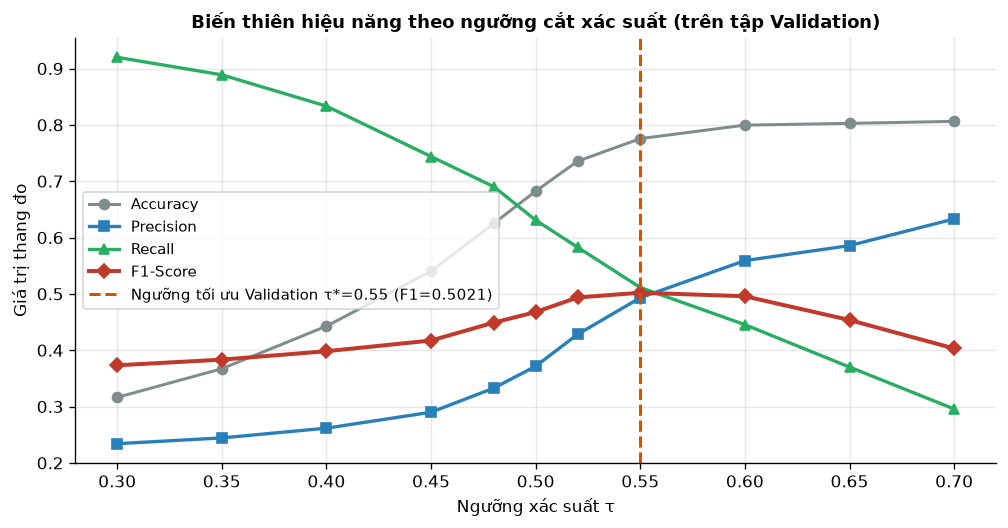

In [22]:
# Đánh giá đa ngưỡng trên tập Validation (Zero-leakage)
thresholds = [0.30, 0.35, 0.40, 0.45, 0.48, 0.50, 0.52, 0.55, 0.60, 0.65, 0.70]
records_val = []

for th in thresholds:
    p_val_th = best_lr.predict(X_val_scaled, threshold=th)
    records_val.append({
        'th': th,
        'acc': float(accuracy_score(y_val, p_val_th)),
        'prec': float(precision_score(y_val, p_val_th)),
        'rec': float(recall_score(y_val, p_val_th)),
        'f1': float(f1_score(y_val, p_val_th))
    })

best_th_rec = max(records_val, key=lambda x: x['f1'])
best_threshold = float(best_th_rec['th'])

print("=== BẢNG RÀ SOÁT NGƯỠNG TRÊN TẬP VALIDATION (N = 4,800) ===")
print(f"{'Ngưỡng (τ)':10s} | {'Accuracy':9s} | {'Precision':9s} | {'Recall':9s} | {'F1-Score':9s}")
print("-" * 55)
for r in records_val:
    mark = " <-- Tối ưu" if r['th'] == best_threshold else ""
    print(f"{r['th']:10.2f} | {r['acc']:9.4f} | {r['prec']:9.4f} | {r['rec']:9.4f} | {r['f1']:9.4f}{mark}")

print(f"\n→ Ngưỡng tối ưu được chọn từ tập Validation: τ* = {best_threshold:.2f} (F1_val = {best_th_rec['f1']:.4f})")

# Đánh giá duy nhất một lần trên tập Test độc lập với ngưỡng τ*
y_test_pred_opt = best_lr.predict(X_test_scaled, threshold=best_threshold)
acc_test_opt    = float(accuracy_score(y_test, y_test_pred_opt))
prec_test_opt   = float(precision_score(y_test, y_test_pred_opt))
rec_test_opt    = float(recall_score(y_test, y_test_pred_opt))
f1_test_opt     = float(f1_score(y_test, y_test_pred_opt))

print("\n=== KẾT QUẢ CUỐI CÙNG TRÊN TẬP TEST ĐỘC LẬP (N = 6,000) ===")
print(f"Accuracy  : {acc_test_opt*100:.2f}%")
print(f"Precision : {prec_test_opt*100:.2f}%")
print(f"Recall    : {rec_test_opt*100:.2f}%")
print(f"F1-Score  : {f1_test_opt:.4f}")
print(f"ROC-AUC   : {auc_best:.4f}")
print(f"PR-AUC    : {prauc_best:.4f}")

# Vẽ đường cong dò ngưỡng trên tập Validation
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot([r['th'] for r in records_val], [r['acc'] for r in records_val], marker='o', label='Accuracy', lw=1.8, color='#7f8c8d')
ax.plot([r['th'] for r in records_val], [r['prec'] for r in records_val], marker='s', label='Precision', lw=2.0, color='#2980b9')
ax.plot([r['th'] for r in records_val], [r['rec'] for r in records_val], marker='^', label='Recall', lw=2.0, color='#27ae60')
ax.plot([r['th'] for r in records_val], [r['f1'] for r in records_val], marker='D', label='F1-Score', lw=2.4, color='#c0392b')
ax.axvline(best_threshold, color='#d35400', linestyle='--', lw=1.8, label=f"Ngưỡng tối ưu Validation τ*={best_threshold:.2f} (F1={best_th_rec['f1']:.4f})")
ax.set_title("Biến thiên hiệu năng theo ngưỡng cắt xác suất (trên tập Validation)", fontweight='bold', fontsize=11)
ax.set_xlabel("Ngưỡng xác suất τ", fontsize=10)
ax.set_ylabel("Giá trị thang đo", fontsize=10)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


In [23]:
# === PHẦN B: Lưu trọng số và tham số ra file ===
os.makedirs("weights", exist_ok=True)
npz_path  = os.path.join("weights", "production_bundle.npz")
json_path = os.path.join("weights", "production_bundle.json")

# 1. File .npz (nhị phân, tải nhanh)
export_npz = {
    'weights': best_lr.weights,
    'bias': np.array([best_lr.bias]),
    'scaler_mean': scaler.mean_,
    'scaler_scale': scaler.scale_,
    'best_th': np.array([best_threshold]),
    'feature_names': np.array(feature_names),
    'C': np.array([best_params['C']]),
    'penalty': np.array([best_params['penalty']]),
    'class_weight': np.array([str(best_params.get('class_weight', 'none'))]),
    'learning_rate': np.array([0.1]),
    'max_iter': np.array([1000])
}
np.savez_compressed(npz_path, **export_npz)

# 2. File .json (text, dễ audit)
export_json = {
    'weights': best_lr.weights.tolist(),
    'bias': float(best_lr.bias),
    'scaler_mean': scaler.mean_.tolist(),
    'scaler_scale': scaler.scale_.tolist(),
    'best_threshold': float(best_threshold),
    'feature_names': feature_names,
    'hyperparameters': {
        'C': float(best_params['C']),
        'penalty': best_params['penalty'],
        'class_weight': str(best_params.get('class_weight', 'none')),
        'learning_rate': 0.1,
        'max_iter': 1000
    }
}
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(export_json, f, ensure_ascii=False, indent=2)

print(f"Đã lưu file NPZ : {npz_path} ({os.path.getsize(npz_path):,} bytes)")
print(f"Đã lưu file JSON : {json_path} ({os.path.getsize(json_path):,} bytes)")


Đã lưu file NPZ : weights\production_bundle.npz (3,051 bytes)
Đã lưu file JSON : weights\production_bundle.json (2,827 bytes)


In [24]:
# === PHẦN C: Kiểm định tải lại và đóng gói Pipeline ===

# Kiểm tra tải lại từ .npz
bundle = np.load(npz_path, allow_pickle=True)
lr_verify = LogisticRegression(
    C=float(bundle['C'][0]),
    penalty=str(bundle['penalty'][0]) if str(bundle['penalty'][0]) != 'none' else None,
    class_weight=str(bundle['class_weight'][0]) if str(bundle['class_weight'][0]) != 'none' else None
)
lr_verify.weights = bundle['weights'].copy()
lr_verify.bias = float(bundle['bias'][0])

scaler_verify = StandardScaler()
scaler_verify.mean_  = bundle['scaler_mean'].copy()
scaler_verify.scale_ = bundle['scaler_scale'].copy()

y_proba_verify = lr_verify.predict_proba(scaler_verify.transform(X_test))[:, 1]
match = np.allclose(y_proba_verify, y_proba_best, atol=1e-12)
print(f"Kiểm định tải lại NPZ — allclose: {match}")
print(f"Max sai khác: {np.max(np.abs(y_proba_verify - y_proba_best)):.2e}")


Kiểm định tải lại NPZ — allclose: True
Max sai khác: 0.00e+00


In [25]:
# Đóng gói Pipeline suy luận và Demo kiểm thử thực tế
from model import CreditDefaultInferencePipeline

pipeline = CreditDefaultInferencePipeline(best_lr, scaler, best_threshold, feature_names)

# Demo: lấy 1 mẫu thật từ test set
sample_idx = 42
sample_features = X_test[sample_idx:sample_idx+1]
sample_proba = float(pipeline.predict_proba(sample_features)[0])
sample_pred  = int(pipeline.predict(sample_features)[0])
true_label   = int(y_test[sample_idx])
decision_txt = "CẢNH BÁO NỢ XẤU / TỪ CHỐI CẤP TÍN DỤNG" if sample_pred == 1 else "AN TOÀN / CHẤP THUẬN CẤP TÍN DỤNG"

print("=" * 70)
print(f"DEMO PIPELINE SUY LUẬN — Khách hàng mẫu #{sample_idx} từ Test Set")
print("=" * 70)
print(f"  Xác suất vỡ nợ dự báo : {sample_proba:.4f}  ({sample_proba*100:.2f}%)")
print(f"  Ngưỡng cắt tối ưu τ*  : {pipeline.threshold:.4f}")
print(f"  Quyết định tự động    : {decision_txt} (Nhãn {sample_pred})")
print(f"  Thực tế đối chiếu     : {'Nợ xấu (Nhãn 1)' if true_label == 1 else 'Đúng hạn (Nhãn 0)'}")
print(f"  Đánh giá              : {'CHÍNH XÁC ✓' if sample_pred == true_label else 'CẦN THẨM ĐỊNH LẠI ✗'}")
print("=" * 70)


DEMO PIPELINE SUY LUẬN — Khách hàng mẫu #42 từ Test Set
  Xác suất vỡ nợ dự báo : 0.4348  (43.48%)
  Ngưỡng cắt tối ưu τ*  : 0.5500
  Quyết định tự động    : AN TOÀN / CHẤP THUẬN CẤP TÍN DỤNG (Nhãn 0)
  Thực tế đối chiếu     : Đúng hạn (Nhãn 0)
  Đánh giá              : CHÍNH XÁC ✓
